Make Use of Logistic Regression Using The Breast Cancer Dataset To Find Whether a Sample Is Benign or Malignant


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline

In [4]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

print(data.target_names)


['malignant' 'benign']


In [5]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [6]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,random_state=42))
model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True



Class Distribution:
       Class  Count  Probability
0  malignant    212     0.372583
1     benign    357     0.627417


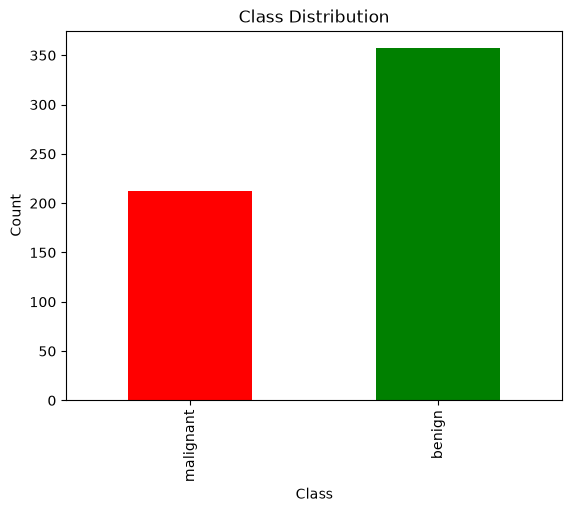

In [17]:
# Class distribution of the dataset with probability
class_counts = y.value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Class": ["malignant", "benign"],
    "Count": class_counts.values,
    "Probability": class_counts.values / len(y)
})

print("\nClass Distribution:")
print(class_distribution)

class_distribution.plot(
    x="Class",
    y="Count",
    kind="bar",
    color=["red", "green"],
    legend=False
)

plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [ ]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:
[[41  1]
 [ 1 71]]


In [35]:
model1 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

model1.fit(x_train, y_train)

y_prob1 = model1.predict_proba(x_test)[:, 1]
y_pred1 = (y_prob1 >= 0.7).astype(int)

print("\nConfusion Matrix with threshold 0.7:")
print(confusion_matrix(y_test, y_pred1))

print("\nPredicted Probabilities:")
print(y_prob1[:10])


Confusion Matrix with threshold 0.7:
[[41  1]
 [ 5 67]]

Predicted Probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


In [36]:
y_prob2 = model1.predict_proba(x_test)[:, 1]
y_pred2 = (y_prob2 >= 0.3).astype(int)

print("\nConfusion Matrix with threshold 0.3:")
print(confusion_matrix(y_test, y_pred2))

print("\nPredicted Probabilities:")
print(y_prob2[:10])


Confusion Matrix with threshold 0.3:
[[40  2]
 [ 0 72]]

Predicted Probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


In [37]:
y_prob3 = model1.predict_proba(x_test)[:, 1]
y_pred3 = (y_prob3 >= 0.5).astype(int)

print("\nConfusion Matrix with threshold 0.5:")
print(confusion_matrix(y_test, y_pred3))

print("\nPredicted Probabilities:")
print(y_prob3[:10])


Confusion Matrix with threshold 0.5:
[[41  1]
 [ 1 71]]

Predicted Probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]
